## HW 11

In [2]:
import pygad
import numpy as np

In [3]:
# Item spaces
item_spaces = np.array([0.751, 8.99e-06, 0.4, 0.29, 0.2, 0.0035, 0.496, 0.0424, 0.0544, 0.0319, 0.635, 0.87, 0.498, 0.527])

# Item prices
item_prices = np.array([999.9, 2199.12, 4346.99, 3999.9, 2999.0, 2499.9, 199.9, 308.66, 429.9, 299.29, 849.0, 1199.89, 1999.9, 3999.0])

# Сapacity of the truck
truck_limit = 3.0

In [4]:
def fitness_func(ga_instance, solution, solution_idx):
    
    # Total volume of the selected items
    total_volume = np.sum(solution * item_spaces)
    
    # Total profit of the selected items
    total_profit = np.sum(solution * item_prices)
    
    # Penalty logic
    if total_volume > truck_limit:
        # Hard penalty: if it exceeds 3.0, the score drops to 1
        fitness = 1.0 
    else:
        # If it fits in the truck, the fitness score is the profit itself
        fitness = total_profit
        
    return fitness

In [7]:
# GA Parameters 
num_generations = 50       
sol_per_pop = 10           
num_parents_mating = 4   
num_genes = len(item_prices)
gene_space = [0, 1]

# Initializing the GA Engine 
ga_base = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       fitness_func=fitness_func, 
                       sol_per_pop=sol_per_pop,
                       num_genes=num_genes,
                       gene_space=gene_space,
                       crossover_type="single_point", 
                       mutation_type="random",
                       mutation_percent_genes=10)

Best chromosome: [0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1.]
Total Profit (Fitness): $24281.55
Total Volume: 2.91720899 m^3 (Limit: 3.0 m^3)


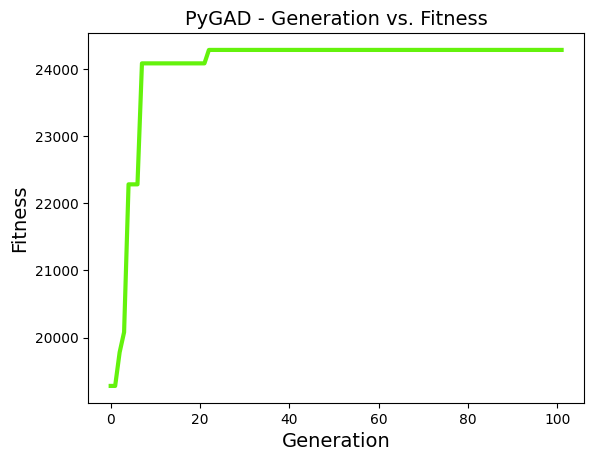

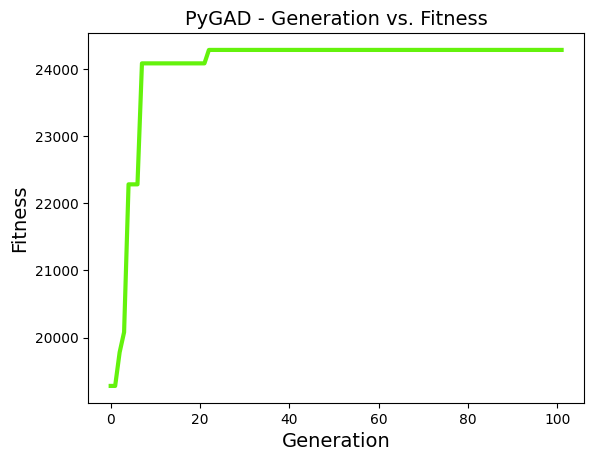

In [9]:
ga_base.run()

# Extract the best solution
solution, solution_fitness, solution_idx = ga_base.best_solution()
best_volume = np.sum(solution * item_spaces)

print(f"Best chromosome: {solution}")
print(f"Total Profit (Fitness): ${solution_fitness}")
print(f"Total Volume: {best_volume} m^3 (Limit: {truck_limit} m^3)")

# Visualize
ga_base.plot_fitness()

### Experiments

Best chromosome: [1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 1.]
Total Profit (Fitness): $19482.37
Total Volume: 2.7608089899999997 m^3 (Limit: 3.0 m^3)


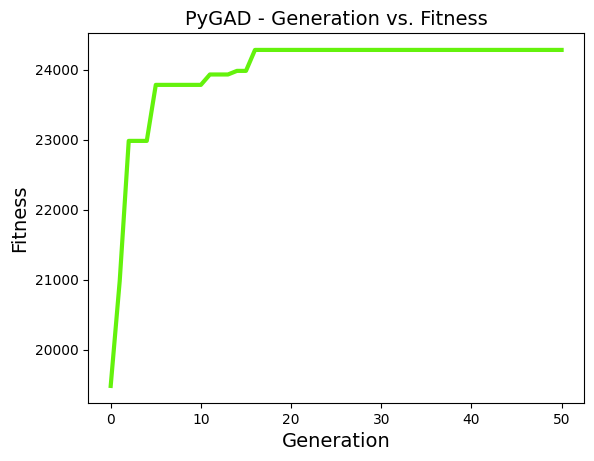

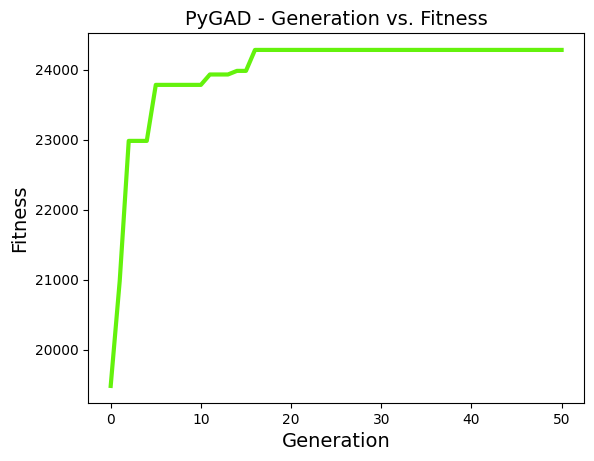

In [12]:
# Uniform
ga_uniform = pygad.GA(
    num_generations=num_generations,
    num_parents_mating=num_parents_mating,
    fitness_func=fitness_func,
    sol_per_pop=sol_per_pop,
    num_genes=num_genes,
    gene_space=gene_space,
    crossover_type="uniform", # CHANGED PARAMETER
    mutation_type="random",
    mutation_percent_genes=10
)

# Extract the best solution
solution, solution_fitness, solution_idx = ga_uniform.best_solution()
best_volume = np.sum(solution * item_spaces)

print(f"Best chromosome: {solution}")
print(f"Total Profit (Fitness): ${solution_fitness}")
print(f"Total Volume: {best_volume} m^3 (Limit: {truck_limit} m^3)")

ga_uniform.run()
ga_uniform.plot_fitness()

Best chromosome: [0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1.]
Total Profit (Fitness): $18126.72
Total Volume: 1.5729089900000002 m^3 (Limit: 3.0 m^3)


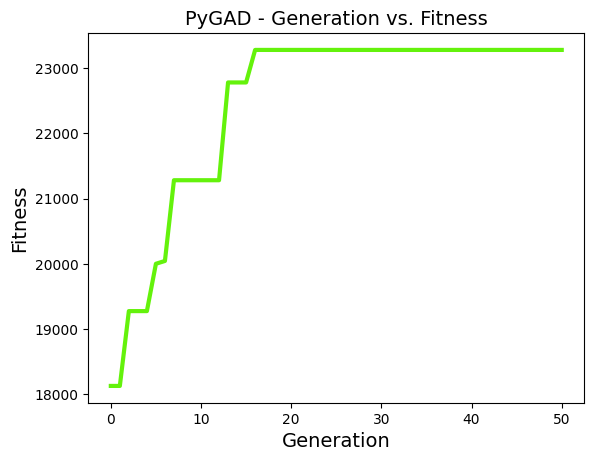

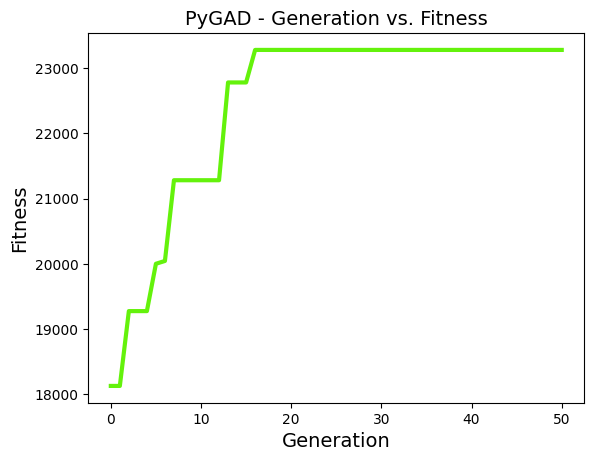

In [13]:
# Higher Mutation
ga_mutation = pygad.GA(
    num_generations=num_generations,
    num_parents_mating=num_parents_mating,
    fitness_func=fitness_func,
    sol_per_pop=sol_per_pop,
    num_genes=num_genes,
    gene_space=gene_space,
    crossover_type="single_point", 
    mutation_type="random",
    mutation_percent_genes=30
)
# Extract the best solution
solution, solution_fitness, solution_idx = ga_mutation.best_solution()
best_volume = np.sum(solution * item_spaces)

print(f"Best chromosome: {solution}")
print(f"Total Profit (Fitness): ${solution_fitness}")
print(f"Total Volume: {best_volume} m^3 (Limit: {truck_limit} m^3)")

ga_mutation.run()
ga_mutation.plot_fitness()